# Análisis de Operaciones — Enfoque complementario con Random Forest
## ¿Cómo afecta el número de habitaciones, baños y camas a la disponibilidad media? ¿Difiere entre ciudades?

---
### Para qué sirve este notebook
Este es el **complemento técnico** del análisis principal
(*2026_06_08_Analisis_Operaciones*). Mientras el notebook principal mide la relación con
**correlaciones de Spearman y regresión estandarizada**, aquí usamos un **Random Forest** (modelo de
árboles) para comprobar, por una vía **no lineal e independiente**, que se llega a las **mismas
conclusiones**. En concreto:

1. **¿Qué variable de tamaño pesa más** (habitaciones, baños, camas) frente a la ciudad? →
   *importancia de variables.* Es el aporte principal de este notebook.
2. **¿Difiere el efecto del tamaño entre ciudades?** → *un modelo por ciudad.*

> **Coherencia con el principal.** aquí **no incluimos `accommodates`** (capacidad declarada): es casi redundante con las camas y respecto al principal —que nunca la menciona—. Se comprueba más abajo que aunque se incluyera **no cambia las conclusiones**.

> **Cómo encaja con el principal.** La **respuesta de negocio integrada** (pregunta, hallazgos,
> limitaciones y propuestas a Dirección) está en la **sección 4 del notebook principal**. Este notebook
> aporta el respaldo de robustez: sus resultados se citan allí como *RF §2, §3 y §5*. El Random Forest
> **coincide y refuerza** la conclusión del principal.

# 0.- Librerías y carga

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import r2_score, mean_absolute_error

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True; plt.rcParams['grid.alpha'] = 0.3

In [3]:
df = pd.read_parquet('2026_06_08_pisos_turisticos_limpio.parquet')
ETIQUETAS = {'bedrooms':'Habitaciones','bathrooms':'Baños','beds':'Camas',
             'city_code':'Ciudad'}
print(f"Alojamientos: {len(df):,}")
df[['city','bedrooms','bathrooms','beds','availability_365']].head()

Alojamientos: 9,650


,city,bedrooms,bathrooms,beds,availability_365
0,malaga,1.0,2.0,1.0,130
1,madrid,1.0,1.0,1.0,162
2,sevilla,2.0,1.0,2.0,270
3,barcelona,1.0,2.0,1.0,300
4,girona,2.0,1.0,5.0,312


---
# 1.- Preparación del modelo

Predecimos `availability_365` a partir del **tamaño** (habitaciones, baños, camas), añadiendo la
**ciudad** como contexto, para poder comparar cuánto pesa cada variable de tamaño frente a las demás y
frente a la ciudad. Usamos las **mismas tres dimensiones de tamaño que el
notebook principal**.

In [4]:
# Codificamos la ciudad como variable numérica (para medir su peso junto al tamaño)
df['city_code'] = df['city'].astype('category').cat.codes
ciudades = dict(enumerate(df['city'].astype('category').cat.categories))

FEATURES = ['bedrooms', 'bathrooms', 'beds', 'city_code']
X = df[FEATURES]
y = df['availability_365']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("Entrenamiento:", X_train.shape, "| Test:", X_test.shape)

Entrenamiento: (7237, 4) | Test: (2413, 4)


# 2.- Entrenamiento del modelo

In [5]:
rf = RandomForestRegressor(n_estimators=300, max_depth=10,
                           min_samples_leaf=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)
r2_cv = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("MODELO SIN 'accommodates' (3 var. de tamaño + ciudad):")
print(f"  R² en test:           {r2_score(y_test, pred):.4f}")
print(f"  R² validación cruzada: {r2_cv.mean():.4f} (±{r2_cv.std():.3f})")
print(f"  Error medio absoluto:  {mean_absolute_error(y_test, pred):.1f} noches")
print(f"  (Para referencia, la desviación de la disponibilidad es {y.std():.0f} noches)")

# --- Comprobación: ¿cambia algo si AÑADIMOS accommodates?
Xa = df[['bedrooms', 'bathrooms', 'beds', 'accommodates', 'city_code']]
rfa = RandomForestRegressor(n_estimators=300, max_depth=10,
                            min_samples_leaf=20, random_state=42, n_jobs=-1)
r2_cv_a = cross_val_score(rfa, Xa, y, cv=5, scoring='r2')
print(f"\nComprobación — mismo modelo CON 'accommodates': "
      f"R² CV = {r2_cv_a.mean():.4f} (±{r2_cv_a.std():.3f})")
print("=> Incluir o no 'accommodates' deja el R² igual de cercano a 0: no cambia la conclusión.")

MODELO SIN 'accommodates' (3 var. de tamaño + ciudad):
  R² en test:           0.0140
  R² validación cruzada: 0.0101 (±0.018)
  Error medio absoluto:  113.9 noches
  (Para referencia, la desviación de la disponibilidad es 131 noches)

Comprobación — mismo modelo CON 'accommodates': R² CV = 0.0136 (±0.018)
=> Incluir o no 'accommodates' deja el R² igual de cercano a 0: no cambia la conclusión.


**🔧 Lectura técnica.** Con las tres variables de tamaño y la ciudad, el Random Forest tiene un
**R² cercano a 0** (validación cruzada ≈ 0.01): el modelo apenas mejora respecto a predecir siempre la
media, y el error medio (~114 noches) es del orden de la propia desviación de los datos (~131). El tamaño
y la ciudad **no contienen información suficiente** para predecir la disponibilidad de un alojamiento
concreto. La comprobación confirma que **añadir `accommodates` no cambia nada** (R² igual de próximo a
cero): por eso se trabaja con las tres variables de tamaño del principal, sin capacidad.

**🏢 Lectura de negocio.** Coincide con el análisis principal por una vía independiente: **el tamaño y la
ciudad, por sí solos, no permiten anticipar cuántas noches estará disponible un piso.** Los factores que podrian ser
decisivos (precio, estacionalidad, gestión del anfitrión) están fuera de estos datos.

# 3.- ¿Qué variable pesa más? (importancia)

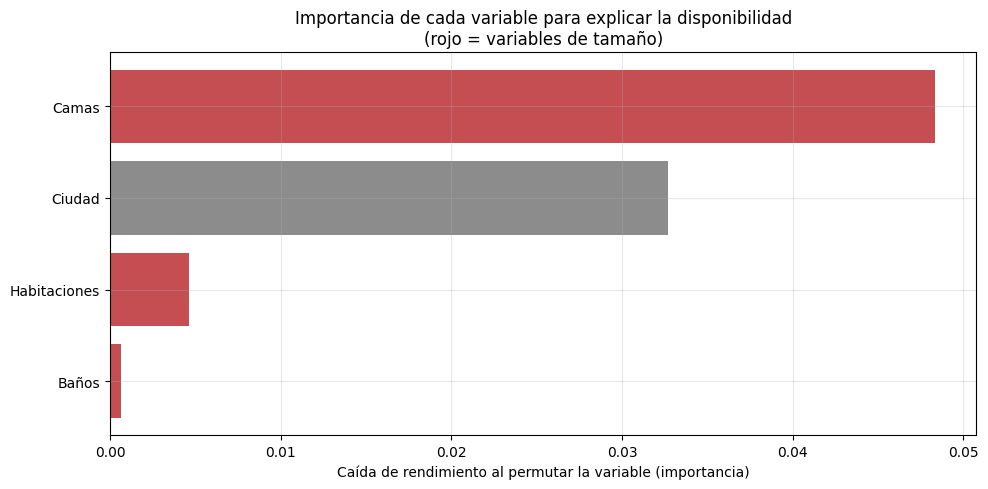

,Importancia
Camas,0.0484
Ciudad,0.0327
Habitaciones,0.0046
Baños,0.0006


In [6]:
# Importancia por permutación (más fiable que la importancia por impureza)
perm = permutation_importance(rf, X_test, y_test, n_repeats=15,
                              random_state=42, n_jobs=-1)
imp = (pd.Series(perm.importances_mean, index=FEATURES)
       .rename(ETIQUETAS).sort_values())

fig, ax = plt.subplots()
colores = ['#C44E52' if n in ('Camas','Habitaciones','Baños') else '#8C8C8C'
           for n in imp.index]
ax.barh(imp.index, imp.values, color=colores)
ax.set_title('Importancia de cada variable para explicar la disponibilidad\n'
             '(rojo = variables de tamaño)')
ax.set_xlabel('Caída de rendimiento al permutar la variable (importancia)')
plt.tight_layout(); plt.show()
display(imp.sort_values(ascending=False).round(4).to_frame('Importancia'))

**🔧 Lectura técnica.** Entre las variables disponibles, la **ciudad** es la que más pesa y, entre
las de tamaño, las **camas (`beds`)** son claramente la más influyente, por delante de habitaciones y
baños (cuya importancia es casi nula). Esto **coincide exactamente con la regresión del notebook
principal**, donde `beds` era la única variable de tamaño significativa. *(Las importancias son bajas en
términos absolutos, coherente con el R² casi nulo: ninguna variable explica gran cosa, pero el orden
relativo entre ellas sí es informativo.)*

**🏢 Lectura de negocio.** Si hay que elegir **una sola métrica de tamaño** para seguir la
disponibilidad, debe ser el **número de camas**, no las habitaciones ni los baños. Es la dimensión que
mejor resume el "tamaño útil" de un alojamiento de cara a la ocupación, y es la misma conclusión a la que
llega el análisis principal.

# 4.- ¿Cómo cambia la disponibilidad con el tamaño? (dependencia parcial)

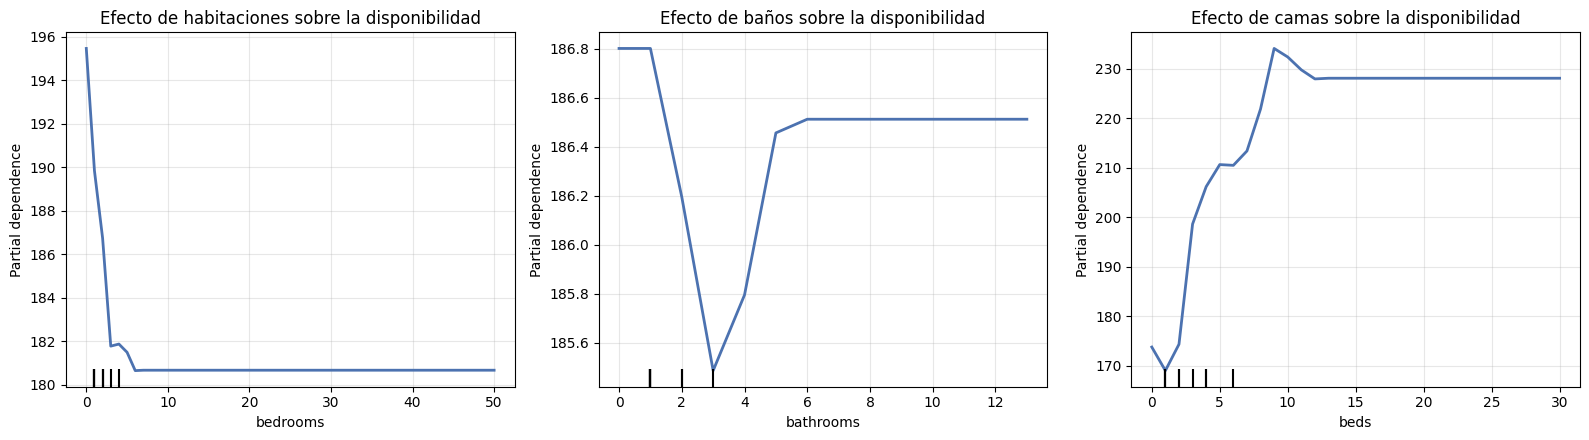

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, feat in zip(axes, ['bedrooms', 'bathrooms', 'beds']):
    PartialDependenceDisplay.from_estimator(
        rf, X, [feat], ax=ax, line_kw={'color': '#4C72B0', 'linewidth': 2})
    ax.set_title(f'Efecto de {ETIQUETAS[feat].lower()} sobre la disponibilidad')
    ax.set_xlabel(ETIQUETAS[feat]); ax.set_ylabel('Disponibilidad estimada (365d)')
plt.tight_layout(); plt.show()

**🔧 Lectura técnica.** Las curvas de dependencia parcial de las tres variables de tamaño son
**suavemente crecientes**: a más camas/habitaciones, el modelo estima algo más de disponibilidad, con
cierta saturación en los tramos altos. La pendiente más marcada es la de **camas**; la de baños es casi
plana. En todos los casos el efecto es de pocas decenas de noches en todo el rango: **real pero modesto**,
sin saltos abruptos. Es la versión no lineal del mismo efecto débil que medía la regresión del principal.

**🏢 Lectura de negocio.** Visualiza la regla operativa: **los alojamientos con más camas acumulan algo
más de noches libres**, sobre todo al pasar de pequeño a mediano. El efecto se aplana en los tamaños
grandes, donde ya intervienen más otros factores que el puro tamaño.

# 5.- ¿Difiere entre ciudades? (un modelo por ciudad)

In [8]:
filas = []
for code_, nombre in ciudades.items():
    sub = df[df['city_code'] == code_]
    if len(sub) < 100:   # solo ciudades con muestra suficiente
        continue
    Xc = sub[['bedrooms','bathrooms','beds']]      # solo tamaño (mismas 3 var. del principal)
    yc = sub['availability_365']
    rfc = RandomForestRegressor(n_estimators=200, max_depth=8,
                                min_samples_leaf=15, random_state=42, n_jobs=-1)
    r2c = cross_val_score(rfc, Xc, yc, cv=4, scoring='r2').mean()
    rfc.fit(Xc, yc)
    imp_c = dict(zip(['bedrooms','bathrooms','beds'],
                     rfc.feature_importances_))
    var_top = max(imp_c, key=imp_c.get)
    filas.append({'Ciudad': nombre, 'Alojamientos': len(sub),
                  'R² (CV)': round(r2c, 3),
                  'Variable+influyente': ETIQUETAS[var_top]})

tabla = pd.DataFrame(filas).sort_values('R² (CV)', ascending=False).set_index('Ciudad')
display(tabla)

,Alojamientos,R² (CV),Variable+influyente
Ciudad,,,
barcelona,2719,0.018,Camas
madrid,2134,-0.009,Camas
malaga,504,-0.016,Camas
mallorca,1583,-0.040,Camas
sevilla,494,-0.050,Camas
girona,1485,-0.054,Camas
valencia,513,-0.070,Camas
menorca,218,-0.101,Camas


**🔧 Lectura técnica.** Al entrenar un modelo de tamaño por ciudad, el poder explicativo es
**positivo solo en Barcelona** (R² de validación cruzada ≈ +0.02) y **nulo o negativo** en los destinos
de costa/insulares (un R² negativo indica que el tamaño no ayuda nada —el modelo predice peor que la
media—). En todas las ciudades la variable de tamaño más influyente son las **camas**. Coincide con el
mapa de correlaciones por ciudad del notebook principal (§3.1).

**🏢 Lectura de negocio.** El modelo confirma que **el tamaño solo es una palanca de gestión útil en
Barcelona**. En Mallorca, Girona o Málaga, intentar anticipar disponibilidad a partir del tamaño no
funciona: la gestión de inventario en esos destinos debe basarse en otros criterios (estacionalidad,
precio, eventos).

---
# 6.- Síntesis del complemento

> **Alcance de este notebook.** Su función es **confirmar**, por una vía no lineal e independiente, las
> conclusiones del análisis principal —no abrir conclusiones nuevas ni proponer acciones distintas—.
> Por eso aquí **no se incluyen propuestas a Dirección**: las propuestas, integradas y citadas, están en
> la **sección 4 del notebook principal** (*2026_06_08_Analisis_Operaciones*), para evitar
> duplicidades o mensajes que pudieran no coincidir.

## En una frase
El Random Forest **coincide con el análisis principal**: el tamaño influye **poco** en la disponibilidad,
de las tres dimensiones de tamaño las **camas** son la más relevante, y el efecto **solo aparece en
Barcelona**.

## Lo que aporta el complemento (en lenguaje de negocio)

1. **Mirar el problema con otra herramienta da el mismo resultado.** Aunque el Random Forest puede captar
   relaciones más complejas que una regresión lineal, no encuentra nada que el análisis principal no
   hubiera visto ya: el tamaño y la ciudad explican muy poco de la disponibilidad de un alojamiento (§2).
   Que dos métodos distintos coincidan da **confianza** en la conclusión.

2. **Confirma cuál es la métrica de tamaño que importa: las camas.** Cuando se mide el peso de cada
   variable, las **camas** quedan por delante de habitaciones y baños (§3) —exactamente la misma jerarquía
   que la regresión del principal—. Para los indicadores de operaciones, "camas" es la dimensión de tamaño
   que conviene seguir.

3. **Confirma que el efecto del tamaño es desigual entre ciudades.** Al analizar cada ciudad por separado,
   **solo en Barcelona** el tamaño se relaciona de forma apreciable con la disponibilidad; en los destinos
   de costa e insulares no aporta nada (§5). Coincide con el mapa por ciudad del principal.

## Qué NO se debe concluir de aquí

- Este notebook **no construye un predictor de disponibilidad**: el modelo no predice con fiabilidad
  (apenas mejora a "usar la media"), y no debe emplearse como herramienta de previsión tal cual.
- El Random Forest **no indica el signo** del efecto (si más camas suben o bajan la disponibilidad): la
  dirección "más tamaño → algo más de disponibilidad" se establece en el principal, con las correlaciones
  y la regresión. Aquí solo se aporta el **orden de importancia** de las variables y la **coincidencia** de
  resultados.

---

> **Conclusión.** El Random Forest **no cambia** la respuesta del análisis principal: la **confirma**. El
> tamaño explica poco la disponibilidad, las **camas** son la dimensión de tamaño más relevante (§3) y el
> efecto solo es apreciable en **Barcelona** (§5). La **respuesta de negocio final, integrada y con
> propuestas**, está en la **sección 4 del notebook principal** (*2026_06_08_Analisis_Operaciones*).